In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import cm
import time
import pandas as pd
import random

In [3]:
def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    np.random.seed(seed)
# 设置随机数种子
setup_seed(123456)

In [4]:
# In[2]:
# 定义网络
class Net(nn.Module):
    def __init__(self, n_input, n_output, n_layer, n_nodes):
        # 调用初始化和定义层数
        super(Net, self).__init__()
        self.n_layer = n_layer
        # 创建输入层Input(给输入数量和神经元节点数量n_input, n_nodes)，Xavier 初始化方法对权重进行初始化，使用正态分布随机初始化偏置
        self.Input = nn.Linear(n_input, n_nodes)
        nn.init.xavier_uniform_(self.Input.weight)
        nn.init.normal_(self.Input.bias)
        # 创建输出层(给神经元节点数量和输出数量)，并对权重和偏置同样进行初始化
        self.Output = nn.Linear(n_nodes, n_output)
        nn.init.xavier_uniform_(self.Output.weight)
        nn.init.normal_(self.Output.bias)
        # 创建隐藏层，n_layer个隐藏层进行循环，输入前后隐藏层节点数量，都是线性层，第二个循环则对权重偏置进行初始化
        self.Hidden = nn.ModuleList() # hidden layer list
        for i in range(n_layer):
            self.Hidden.append(nn.Linear(n_nodes, n_nodes))
        for layer in self.Hidden:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.normal_(layer.bias)


    # 定义向前传播过程
    def forward(self, x):
        y = torch.tanh(self.Input(x)) # tanh activation function
        for layer in self.Hidden:
            y = torch.tanh(layer(y))
        y = self.Output(y)
        return y


In [5]:
def derivativs(R, Net):
    r= Net(R)[:,0].view(-1,1)
    P_r= Net(R)[:,1].view(-1,1)
    return r, P_r

In [6]:
delta=0
miu0=0.1802e6  ####pa
miuA=0.1802e6  ####pa
miuB=0.3166e6  ####pa
A=1                ####m
B=2                ####m
Pa=-0.1e6   ####pa
Pb=0e6


In [7]:
#无量纲
L = A  # 长度无量纲

P=miu0  # 压力无量纲


# 归一化参数
A_bar = A / L
B_bar = B / L
miu0_bar = miu0 /miu0
miuA_bar = miuA /miu0
miuB_bar = miuB /miu0

Pa_bar = Pa / P
Pb_bar = Pb / P

In [8]:
def miu_func(R_bar):
    miu_bar = miu0_bar*R_bar**(np.log(miuB_bar/miuA_bar)/np.log(B_bar/A_bar))
    return miu_bar

In [9]:
def derivativs2(R_bar,  Net_r, miu_func):
    
    r_bar, P_r_bar = derivativs(R_bar, Net_r)

    miu_bar = miu_func(R_bar).view(-1,1)
    
    
    I1=(r_bar/R_bar)**(-2*delta-2)+(r_bar/R_bar)**2+(r_bar/R_bar)**(2*delta)
    I2=(r_bar/R_bar)**(-2*delta)*(r_bar/R_bar)**(-2)+(r_bar/R_bar)**(2*delta+2)
    
        
    W_bar=miu_bar/2*(I1-3)
    W1_bar=miu_bar/2
    W2_bar=0
    
    
    dr_R1=torch.autograd.grad(r_bar, R_bar, torch.ones_like(r_bar), retain_graph=True, create_graph=True, allow_unused=True)
    
    dr_R = dr_R1[0]
    
    J = dr_R*(r_bar/R_bar)**(delta+1)
    
    sigma_r_bar=-P_r_bar+2*W1_bar*dr_R**2+2*W2_bar*((r_bar/R_bar)**2*dr_R**2+(r_bar/R_bar)**(2*delta)*dr_R**2)
    
       
    dsigma_r_R1=torch.autograd.grad(sigma_r_bar, R_bar, torch.ones_like(sigma_r_bar), retain_graph=True, create_graph=True, allow_unused=True)
    
    dsigma_r_R = dsigma_r_R1[0]
    
    dsigma_r_r=dsigma_r_R/(dr_R)
    
           
    
    sigma_theta_bar = -P_r_bar+2*W1_bar*(r_bar/R_bar)**2+2*W2_bar*(dr_R**2*(r_bar/R_bar)**2+(r_bar/R_bar)**(2*delta+2))

#     sigma_z_bar = -P_r_bar+2*W1_bar*(r_bar/R_bar)**(2*delta)+2*W2_bar*(dr_R**2*(r_bar/R_bar)**(2*delta)+(r_bar/R_bar)**(2*delta+2)) 
    
    sigma_z_bar = -P_r_bar+2*W1_bar
    
    return sigma_r_bar, sigma_theta_bar,sigma_z_bar,dsigma_r_r
    

In [10]:
def PDE(R_bar, Net_r, miu_func):
    
    r_bar, P_r_bar = derivativs(R_bar, Net_r)
    
    sigma_r_bar, sigma_theta_bar, _, dsigma_r_r = derivativs2(R_bar,  Net_r, miu_func)
        
    governing_equation_1 = dsigma_r_r+ (delta+1)*(sigma_r_bar - sigma_theta_bar) / r_bar

    return torch.mean(governing_equation_1 ** 2)

In [11]:
def J(R_bar, Net_r, miu_func):
    
    r_bar, P_r_bar = derivativs(R_bar, Net_r)
    
    sigma_r_bar, sigma_theta_bar, _, dsigma_r_r = derivativs2(R_bar,  Net_r, miu_func)
    
    dr_R1 = torch.autograd.grad(r_bar, R_bar, torch.ones_like(r_bar), retain_graph=True, create_graph=True, allow_unused=True)
    
    dr_R = dr_R1[0]

    J = dr_R*(r_bar/R_bar)**(delta+1)

    return torch.mean((J-1) ** 2)

In [12]:
def BD1(R_bar, Net_r, miu_func):
       
    r_bar, P_r_bar = derivativs(R_bar, Net_r)

    
    sigma_r_bar, _, _, _ = derivativs2(R_bar,  Net_r, miu_func)
    
    return torch.mean((sigma_r_bar-Pa_bar) ** 2)

In [13]:
def BD2(R_bar, Net_r, miu_func):
       
    r_bar, P_r_bar = derivativs(R_bar, Net_r)

    
    sigma_r_bar, _, _, _ = derivativs2(R_bar,  Net_r, miu_func)
    
    return torch.mean((sigma_r_bar-Pb_bar) ** 2)

In [14]:
def train_data(Nint):

    R_int_bar =np.linspace(A_bar, B_bar, Nint).reshape([Nint, 1])
    R_b1_bar = A_bar*np.ones((1,1))
    R_b2_bar = B_bar*np.ones((1,1))
    R_int_bar = torch.tensor(R_int_bar, dtype=torch.float32, requires_grad=True)
    R_b1_bar = torch.tensor(R_b1_bar, dtype=torch.float32, requires_grad=True)
    R_b2_bar = torch.tensor(R_b2_bar, dtype=torch.float32, requires_grad=True)

    return R_int_bar, R_b1_bar, R_b2_bar

In [15]:
Nint =2001

R_int_bar, R_b1_bar, R_b2_bar = train_data(Nint)

Net_r = Net(1, 2, 5, 10)


In [16]:
start_time = time.time()
# optimize
nepoches =200000
learning_rate = 1e-4
optimizer = torch.optim.Adam(list(Net_r.parameters()), lr=learning_rate)

loss_PDE = torch.tensor(0.0)
loss_history = []
loss_PDE_history = []
loss_J_history = []
loss_BD1_history = []
loss_BD2_history = []

# Early stopping parameters
patience = 2000  # 允许的最大没有显著变化的周期数
best_loss = float('inf')  # 初始时最小的损失为正无穷
no_improvement_counter = 0  # 用于计数没有改进的周期数

for epoch in range(nepoches):
    # 计算损失
    loss_PDE = PDE(R_int_bar, Net_r, miu_func)
    loss_J = J(R_int_bar, Net_r, miu_func)
    loss_BD1 = BD1(R_b1_bar, Net_r, miu_func)
    loss_BD2 = BD2(R_b2_bar, Net_r, miu_func)
    loss = loss_PDE +10* loss_J + loss_BD1 + loss_BD2

    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

    loss_history.append(loss.item())
    loss_PDE_history.append(loss_PDE.item())
    loss_J_history.append(loss_J.item())
    loss_BD1_history.append(loss_BD1.item())
    loss_BD2_history.append(loss_BD2.item())

    # Check if the loss has improved
    if loss.item() < best_loss:
        best_loss = loss.item()
        no_improvement_counter = 0  # Reset the counter if there's improvement
    else:
        no_improvement_counter += 1

    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'epoch:{epoch + 1}: total loss:{loss:.4e}, loss_PDE:{loss_PDE:.4e}, loss_J:{loss_J:.4e}, loss_BD1:{loss_BD1:.4e}, loss_BD2:{loss_BD2:.4e}')

    # Early stopping condition
    if no_improvement_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}, no improvement in loss for {patience} epochs.")
        break

elapsed_time = time.time() - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

epoch:100: total loss:1.5123e+01, loss_PDE:2.5494e-01, loss_J:9.5014e-01, loss_BD1:3.5483e+00, loss_BD2:1.8184e+00
epoch:200: total loss:1.3933e+01, loss_PDE:1.7073e-01, loss_J:9.3860e-01, loss_BD1:2.9656e+00, loss_BD2:1.4110e+00
epoch:300: total loss:1.2888e+01, loss_PDE:1.3670e-01, loss_J:9.2425e-01, loss_BD1:2.4428e+00, loss_BD2:1.0658e+00
epoch:400: total loss:1.1926e+01, loss_PDE:1.1621e-01, loss_J:9.0394e-01, loss_BD1:1.9867e+00, loss_BD2:7.8323e-01
epoch:500: total loss:1.0994e+01, loss_PDE:1.0515e-01, loss_J:8.7327e-01, loss_BD1:1.5960e+00, loss_BD2:5.5980e-01
epoch:600: total loss:1.0021e+01, loss_PDE:1.0372e-01, loss_J:8.2597e-01, loss_BD1:1.2668e+00, loss_BD2:3.9036e-01
epoch:700: total loss:8.9242e+00, loss_PDE:1.1629e-01, loss_J:7.5414e-01, loss_BD1:9.9664e-01, loss_BD2:2.6991e-01
epoch:800: total loss:7.6367e+00, loss_PDE:1.5975e-01, loss_J:6.4996e-01, loss_BD1:7.8390e-01, loss_BD2:1.9339e-01
epoch:900: total loss:6.1902e+00, loss_PDE:2.7584e-01, loss_J:5.1429e-01, loss_B

In [17]:
# 假设这些都是 list / numpy array，长度 = epoch 数
data = {
    'Epoch': np.arange(1, len(loss_history) + 1),
    'Total_Loss': loss_history,
    'PDE_Loss': loss_PDE_history,
    'J_Loss': loss_J_history,
    'BD1_Loss': loss_BD1_history,
    'BD2_Loss': loss_BD2_history
}

df = pd.DataFrame(data)

# 保存为 CSV
df.to_csv(
    r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\loss_history.csv',
    index=False
)

print(f'loss值已保存')

loss值已保存


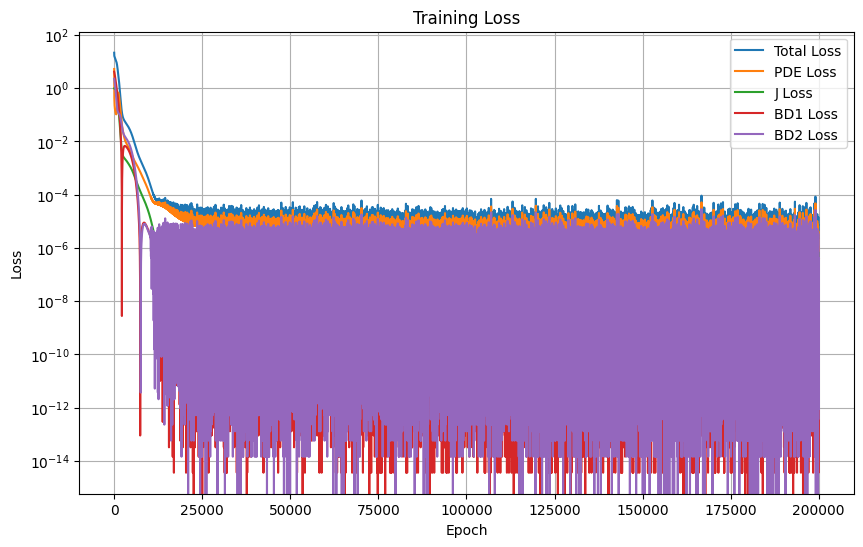

In [18]:
# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Total Loss')
plt.plot(loss_PDE_history, label='PDE Loss')
plt.plot(loss_J_history, label='J Loss')
plt.plot(loss_BD1_history, label='BD1 Loss')
plt.plot(loss_BD2_history, label='BD2 Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.savefig(r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\loss_curve.tiff')
plt.show()

In [19]:
R_test_bar = torch.linspace(A_bar, B_bar,50).view(-1, 1).requires_grad_(True)

# 计算网络输出
r_test_bar, P_r_test_bar = derivativs(R_test_bar, Net_r)

sigma_r_test_bar, sigma_theta_test_bar, sigma_z_test_bar, dsigma_r_r = derivativs2(R_test_bar,  Net_r, miu_func)

                                            
lamdatheta_bar=r_test_bar/R_test_bar

r_test_pred_bar=r_test_bar.detach().numpy().reshape(-1,1)
lamdatheta_pred_bar=lamdatheta_bar.detach().numpy().reshape(-1,1)
sigma_r_test_pred_bar = sigma_r_test_bar.detach().numpy().reshape(-1,1)
sigma_theta_test_pred_bar = sigma_theta_test_bar.detach().numpy().reshape(-1,1)
sigma_z_test_pred_bar = sigma_z_test_bar.detach().numpy().reshape(-1,1)

In [20]:
R_test_np_bar = R_test_bar.detach().numpy()

# 创建一个字典来存储所有数据
data_dict5 = {
    'R_train_bar': R_test_np_bar.flatten(),
    'r_test_pred_bar': r_test_pred_bar.flatten(),
    'lamdatheta_pred_bar': lamdatheta_pred_bar.flatten(),
    'sigma_r_test_pred_bar': sigma_r_test_pred_bar.flatten(),
    'sigma_theta_test_pred_bar': sigma_theta_test_pred_bar.flatten(),
    'sigma_z_test_pred_bar': sigma_z_test_pred_bar.flatten()
}

# 将字典转换为 DataFrame
df5 = pd.DataFrame(data_dict5)

# 保存为 CSV 文件
output_path = r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\CYpredictions.csv'
df5.to_csv(output_path, index=False, encoding='utf-8')


print(f'预测值已保存')

预测值已保存


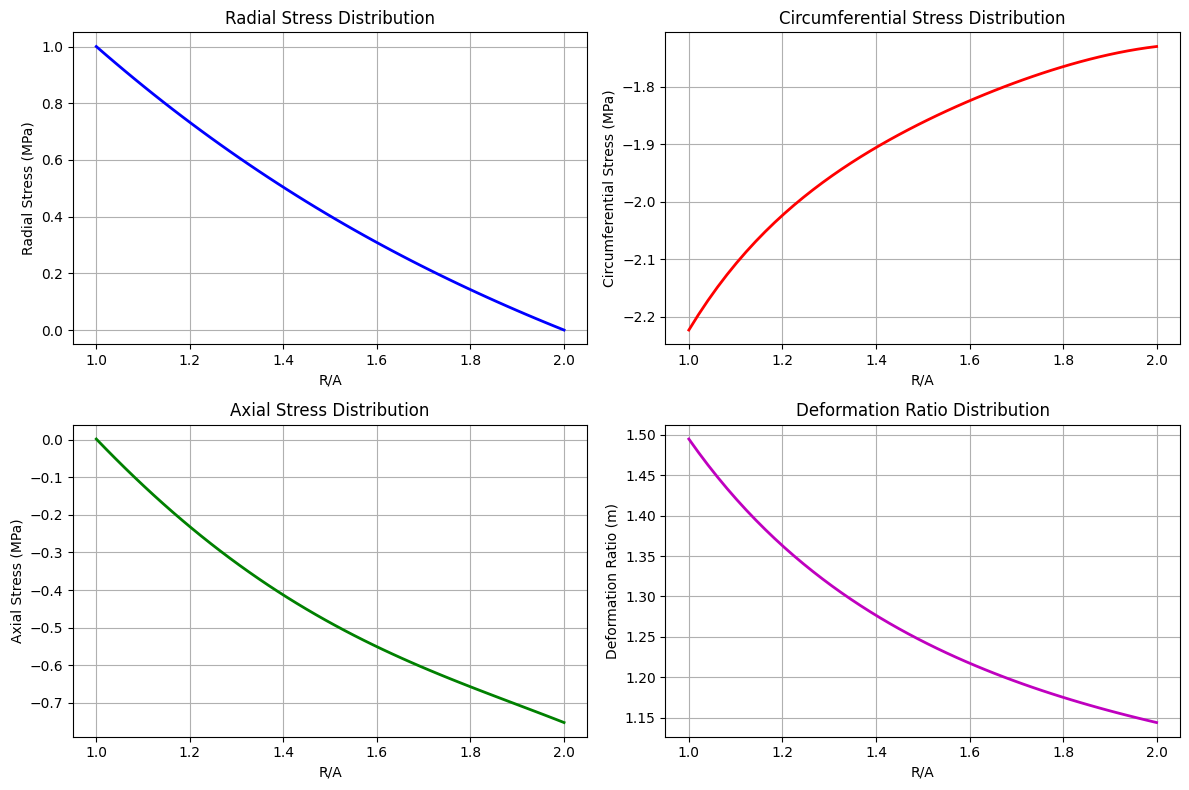


Final Results:
Total training time: 9502.22 seconds
Final loss: 2.2728e-06


In [21]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(R_test_np_bar/A_bar, sigma_r_test_pred_bar*P/Pa, 'b-', linewidth=2)
plt.xlabel('R/A')
plt.ylabel('Radial Stress (MPa)')
plt.title('Radial Stress Distribution')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(R_test_np_bar/A_bar, sigma_theta_test_pred_bar*P/Pa, 'r-', linewidth=2)
plt.xlabel('R/A')
plt.ylabel('Circumferential Stress (MPa)')
plt.title('Circumferential Stress Distribution')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(R_test_np_bar/A_bar, sigma_z_test_pred_bar*P/Pa, 'g-', linewidth=2)
plt.xlabel('R/A')
plt.ylabel('Axial Stress (MPa)')
plt.title('Axial Stress Distribution')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(R_test_np_bar/A_bar,lamdatheta_pred_bar, 'm-', linewidth=2)
plt.xlabel('R/A')
plt.ylabel('Deformation Ratio (m)')
plt.title('Deformation Ratio Distribution')
plt.grid(True)

plt.tight_layout()
plt.savefig(r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\stress_deformation_curves.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()

# 打印最终结果
print("\nFinal Results:")
print(f"Total training time: {elapsed_time:.2f} seconds")
print(f"Final loss: {loss_history[-1]:.4e}")

In [22]:
sigma_r_pred= sigma_r_test_pred_bar*P
sigma_theta_pred=sigma_theta_test_pred_bar *P   
sigma_z_pred=sigma_z_test_pred_bar *P   

In [23]:
vm = np.sqrt(
    sigma_r_pred**2 + sigma_theta_pred**2 + sigma_z_pred**2
    - sigma_r_pred*sigma_theta_pred
    - sigma_theta_pred*sigma_z_pred
    - sigma_r_pred*sigma_z_pred
)
vm_max = np.max(vm)
print(vm_max)

285771.84


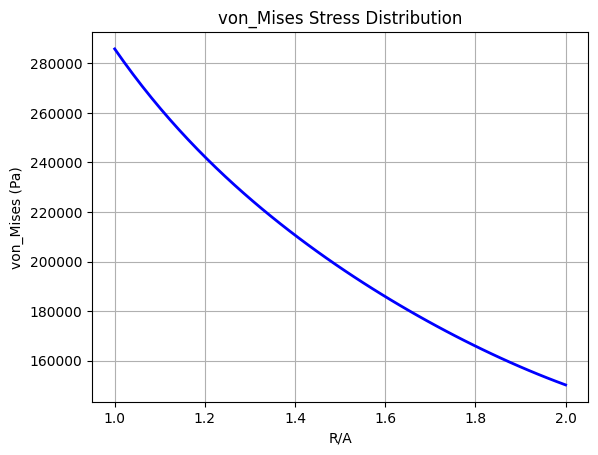

In [24]:
plt.plot(R_test_np_bar, vm, 'b-', linewidth=2)
plt.xlabel('R/A')
plt.ylabel('von_Mises (Pa)')
plt.title('von_Mises Stress Distribution')
plt.grid(True)

In [25]:
data = pd.read_csv('COMSOL_NH_mi_double_zhu.csv')
R_bar = data.iloc[:, 0:1].to_numpy()
sigmar = data.iloc[:, 1:2].to_numpy()
sigmatheta = data.iloc[:, 2:3].to_numpy()
sigmaz = data.iloc[:, 3:4].to_numpy()
lamdatheta = data.iloc[:, 4:5].to_numpy()

In [26]:
# 获取COMSOL数据
COMSOL_R = R_bar.flatten()
COMSOL_sigma_r = sigmar[:,0:1]  
COMSOL_sigma_theta = sigmatheta[:,0:1]  
COMSOL_sigma_z = sigmaz[:, 0:1]  
COMSOL_lamdatheta = lamdatheta[:,0:1] 

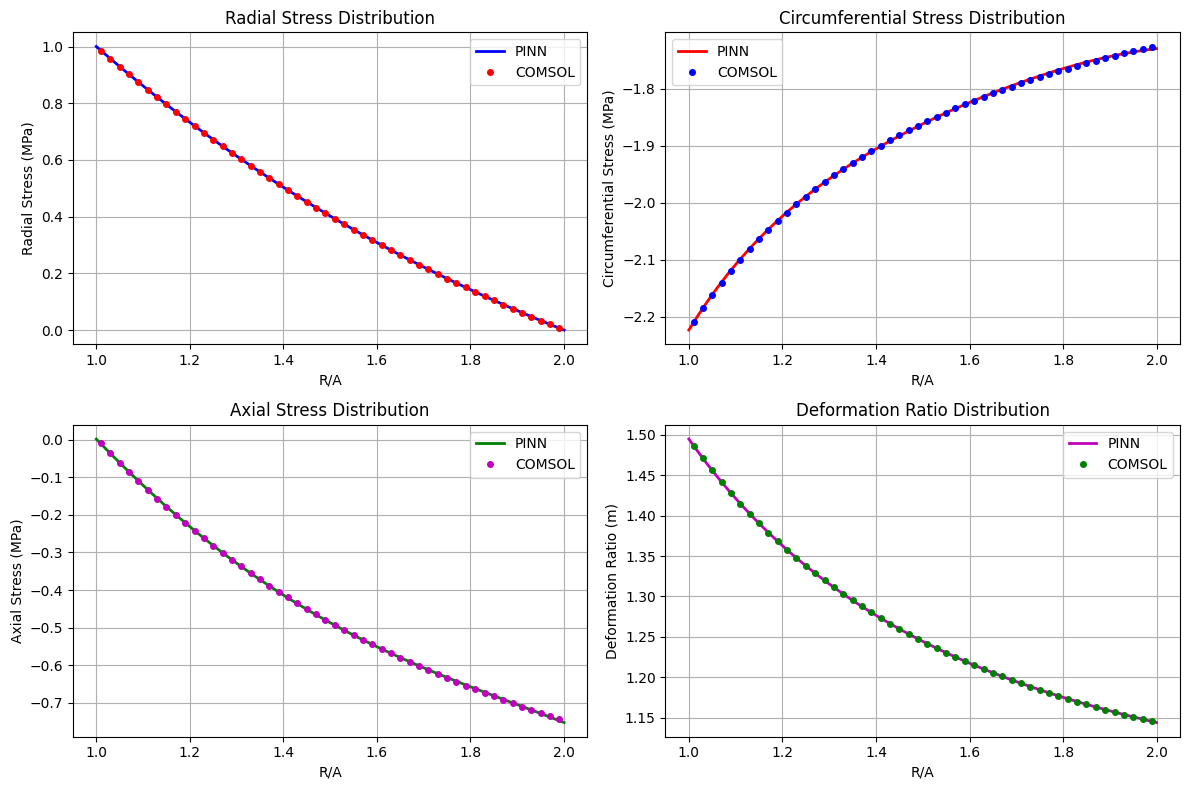


Final Results:
Total training time: 9502.22 seconds
Final loss: 2.2728e-06


In [27]:
plt.figure(figsize=(12, 8))


plt.subplot(2, 2, 1)
plt.plot(R_test_np_bar/A_bar, sigma_r_test_pred_bar*P/Pa, 'b-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_sigma_r, 'ro', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Radial Stress (MPa)')
plt.title('Radial Stress Distribution')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(R_test_np_bar/A_bar, sigma_theta_test_pred_bar*P/Pa, 'r-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_sigma_theta, 'bo', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Circumferential Stress (MPa)')
plt.title('Circumferential Stress Distribution')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(R_test_np_bar/A_bar, sigma_z_test_pred_bar*P/Pa, 'g-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_sigma_z, 'mo', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Axial Stress (MPa)')
plt.title('Axial Stress Distribution')

plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(R_test_np_bar/A_bar, lamdatheta_pred_bar, 'm-', linewidth=2, label='PINN')
plt.plot(COMSOL_R, COMSOL_lamdatheta, 'go', markersize=4, label='COMSOL')
plt.xlabel('R/A')
plt.ylabel('Deformation Ratio (m)')
plt.title('Deformation Ratio Distribution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\stress_deformation_comparison.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()


# 打印最终结果
print("\nFinal Results:")
print(f"Total training time: {elapsed_time:.2f} seconds")
print(f"Final loss: {loss_history[-1]:.4e}")

In [28]:
# 创建极坐标网格
theta = np.linspace(0, 2 * np.pi, 100)
R = R_test_np_bar.flatten()  # 展平半径数组
Theta, R_grid = np.meshgrid(theta, R)
X = R_grid * np.cos(Theta)
Y = R_grid * np.sin(Theta)

# 将一维预测数据扩展为二维网格数据
sigma_r_2d = np.tile(sigma_r_test_pred_bar.flatten() * P / Pa, (len(theta), 1)).T
sigma_theta_2d = np.tile(sigma_theta_test_pred_bar.flatten() * P / Pa, (len(theta), 1)).T
sigma_z_2d = np.tile(sigma_z_test_pred_bar.flatten() * P / Pa, (len(theta), 1)).T
lamdatheta_2d = np.tile(lamdatheta_pred_bar.flatten(), (len(theta), 1)).T

In [29]:
data_dict = {
    'R': R_grid.flatten(),  # 半径网格
    'Theta': Theta.flatten(),  # 角度网格
    'X': X.flatten(),  # X坐标
    'Y': Y.flatten(),  # Y坐标
    'sigma_r_2d': sigma_r_2d.flatten(),  # σ_r 数据
    'sigma_theta_2d': sigma_theta_2d.flatten(),  # σ_θ 数据
    'sigma_z_2d': sigma_z_2d.flatten(),  # σ_z 数据
    'lamdatheta_2d': lamdatheta_2d.flatten()  # λθ 数据
}

# 将字典转换为 DataFrame
df = pd.DataFrame(data_dict)

# 保存为 CSV 文件
output_path = r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\CY_2D_data.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f'极坐标数据已保存到 {output_path}')

极坐标数据已保存到 D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\CY_2D_data.csv


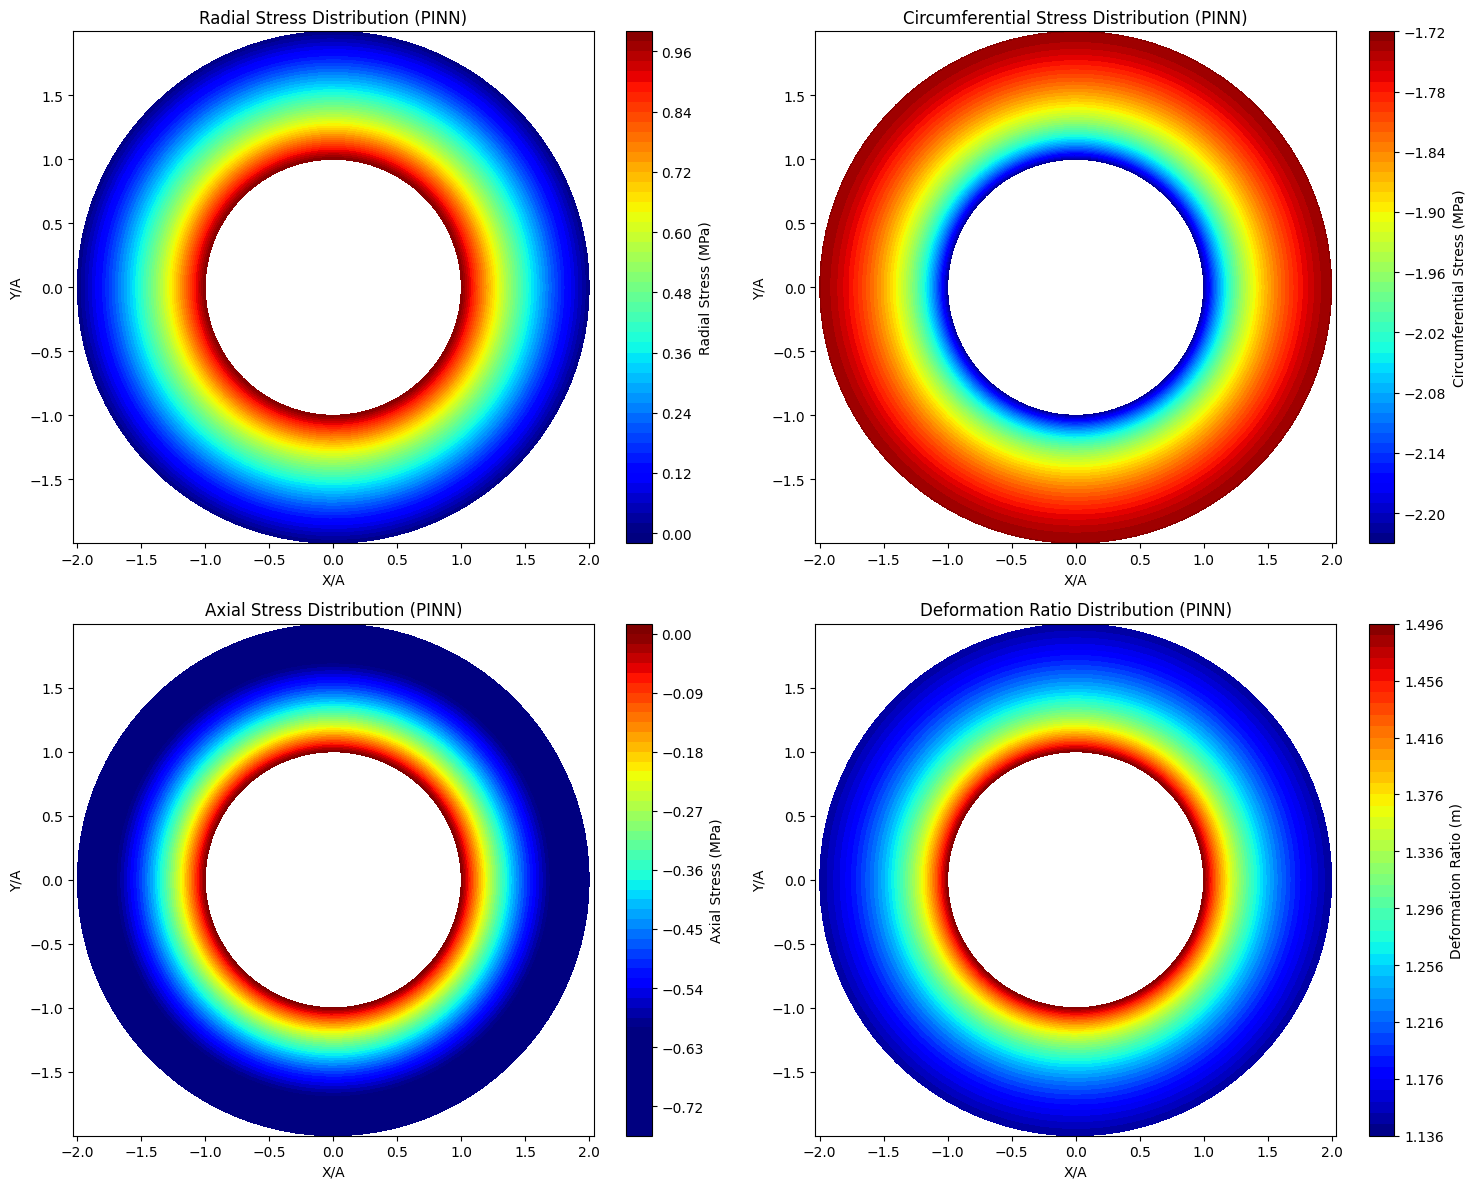


Final Results:
Total training time: 9502.22 seconds
Final loss: 2.2728e-06


In [30]:
# 创建图形
plt.figure(figsize=(15, 12))

# 径向应力分布
plt.subplot(2, 2, 1)
contour1 = plt.contourf(X/A_bar, Y/A_bar, sigma_r_2d, 50, cmap='jet',vmin=0, vmax=1)
plt.colorbar(contour1,label='Radial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Radial Stress Distribution (PINN)')
plt.axis('equal')

# 环向应力分布
plt.subplot(2, 2, 2)
contour2 = plt.contourf(X/A_bar, Y/A_bar, sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour2, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Circumferential Stress Distribution (PINN)')
plt.axis('equal')

# 轴向应力分布
plt.subplot(2, 2, 3)
contour3 = plt.contourf(X/A_bar, Y/A_bar, sigma_z_2d, 50, cmap='jet',vmin=-0.6, vmax=0)

plt.colorbar(contour3, label='Axial Stress (MPa)')

plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Axial Stress Distribution (PINN)')
plt.axis('equal')

# 变形比分布
plt.subplot(2, 2, 4)
contour4 = plt.contourf(X/A_bar, Y/A_bar, lamdatheta_2d, 50, cmap='jet')
plt.colorbar(contour4, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Deformation Ratio Distribution (PINN)')
plt.axis('equal')

plt.tight_layout()
plt.savefig(r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\PINN_2D_distribution.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()

# 打印最终结果
print("\nFinal Results:")
print(f"Total training time: {elapsed_time:.2f} seconds")
print(f"Final loss: {loss_history[-1]:.4e}")

In [31]:
# 创建极坐标网格
theta = np.linspace(0, 2 * np.pi, 100)
R_1 = COMSOL_R.flatten()  # 展平半径数组
Theta, R_grid1 = np.meshgrid(theta, R_1)
X = R_grid1 * np.cos(Theta)
Y = R_grid1 * np.sin(Theta)

# 将一维FDM数据扩展为二维网格数据
COMSOL_sigma_r_2d = np.tile(COMSOL_sigma_r.flatten(), (len(theta), 1)).T
COMSOL_sigma_theta_2d = np.tile(COMSOL_sigma_theta.flatten(), (len(theta), 1)).T
COMSOL_sigma_z_2d = np.tile(COMSOL_sigma_z.flatten() , (len(theta), 1)).T
COMSOL_lamdatheta_2d = np.tile(COMSOL_lamdatheta.flatten(), (len(theta), 1)).T

In [32]:
data_dict = {
    'R_1': R_grid1.flatten(),  # 半径网格
    'Theta': Theta.flatten(),  # 角度网格
    'X': X.flatten(),  # X坐标
    'Y': Y.flatten(),  # Y坐标
    'COMSOL_sigma_r_2d': COMSOL_sigma_r_2d.flatten(),  # σ_r 数据
    'COMSOL_sigma_theta_2d': COMSOL_sigma_theta_2d.flatten(),  # σ_θ 数据
    'COMSOL_sigma_z_2d': COMSOL_sigma_z_2d.flatten(),  # σ_z 数据
    'COMSOL_lamdatheta_2d': COMSOL_lamdatheta_2d.flatten()  # λθ 数据
}

# 将字典转换为 DataFrame
df = pd.DataFrame(data_dict)

# 保存为 CSV 文件
output_path = r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\COMSOL_2D_data.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f'极坐标数据已保存到 {output_path}')

极坐标数据已保存到 D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\COMSOL_2D_data.csv


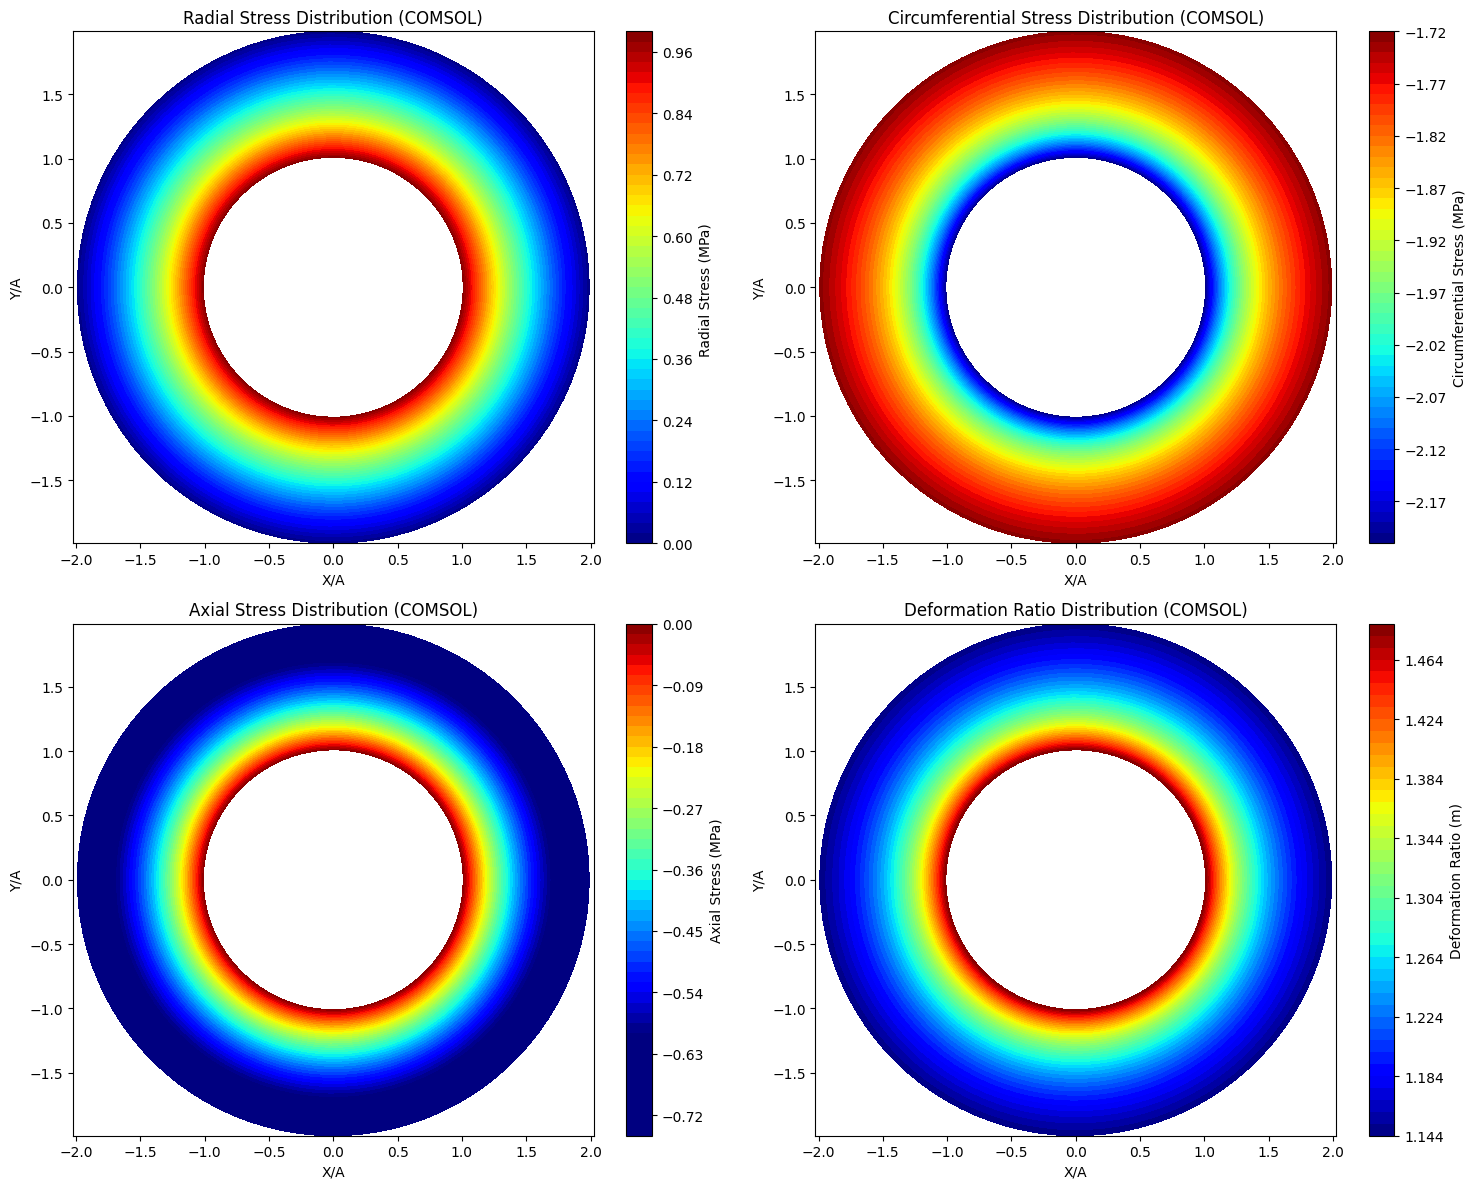

In [33]:


# 创建图形
plt.figure(figsize=(15, 12))
# 径向应力分布
plt.subplot(2, 2, 1)
contour1 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_sigma_r_2d, 50, cmap='jet')
plt.colorbar(contour1, label='Radial Stress (MPa) ')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Radial Stress Distribution (COMSOL)')
plt.axis('equal')

# 环向应力分布
plt.subplot(2, 2, 2)
contour2 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour2, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Circumferential Stress Distribution (COMSOL)')
plt.axis('equal')

# 轴向应力分布
plt.subplot(2, 2, 3)
contour3 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_sigma_z_2d, 50, cmap='jet',vmin=-0.6, vmax=0)
plt.colorbar(contour3, label='Axial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Axial Stress Distribution (COMSOL)')
plt.axis('equal')

# 变形比分布
plt.subplot(2, 2, 4)
contour4 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_lamdatheta_2d, 50, cmap='jet')
plt.colorbar(contour4, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Deformation Ratio Distribution (COMSOL)')
plt.axis('equal')

plt.tight_layout()
plt.savefig(r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\COMSOL_2D_distribution_nf1.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()

In [34]:
sigma_r_2d_error= abs(sigma_r_2d-COMSOL_sigma_r_2d)
sigma_theta_2d_error= abs(sigma_theta_2d-COMSOL_sigma_theta_2d)
sigma_z_2d_error=abs(sigma_z_2d-COMSOL_sigma_z_2d)
lamdatheta_2d_error=abs(lamdatheta_2d-COMSOL_lamdatheta_2d)

In [35]:
data_dict = {
    'R': R_grid.flatten(),  # 半径网格
    'Theta': Theta.flatten(),  # 角度网格
    'X': X.flatten(),  # X坐标
    'Y': Y.flatten(),  # Y坐标
    'sigma_r_2d': sigma_r_2d_error.flatten(),  # σ_r 数据
    'sigma_theta_2d': sigma_theta_2d_error.flatten(),  # σ_θ 数据
    'sigma_z_2d': sigma_z_2d_error.flatten(),  # σ_z 数据
    'lamdatheta_2d': lamdatheta_2d_error.flatten()  # λθ 数据
}

# 将字典转换为 DataFrame
df = pd.DataFrame(data_dict)

# 保存为 CSV 文件
output_path = r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\CY_2D_error.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f'极坐标数据已保存到 {output_path}')

极坐标数据已保存到 D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\CY_2D_error.csv


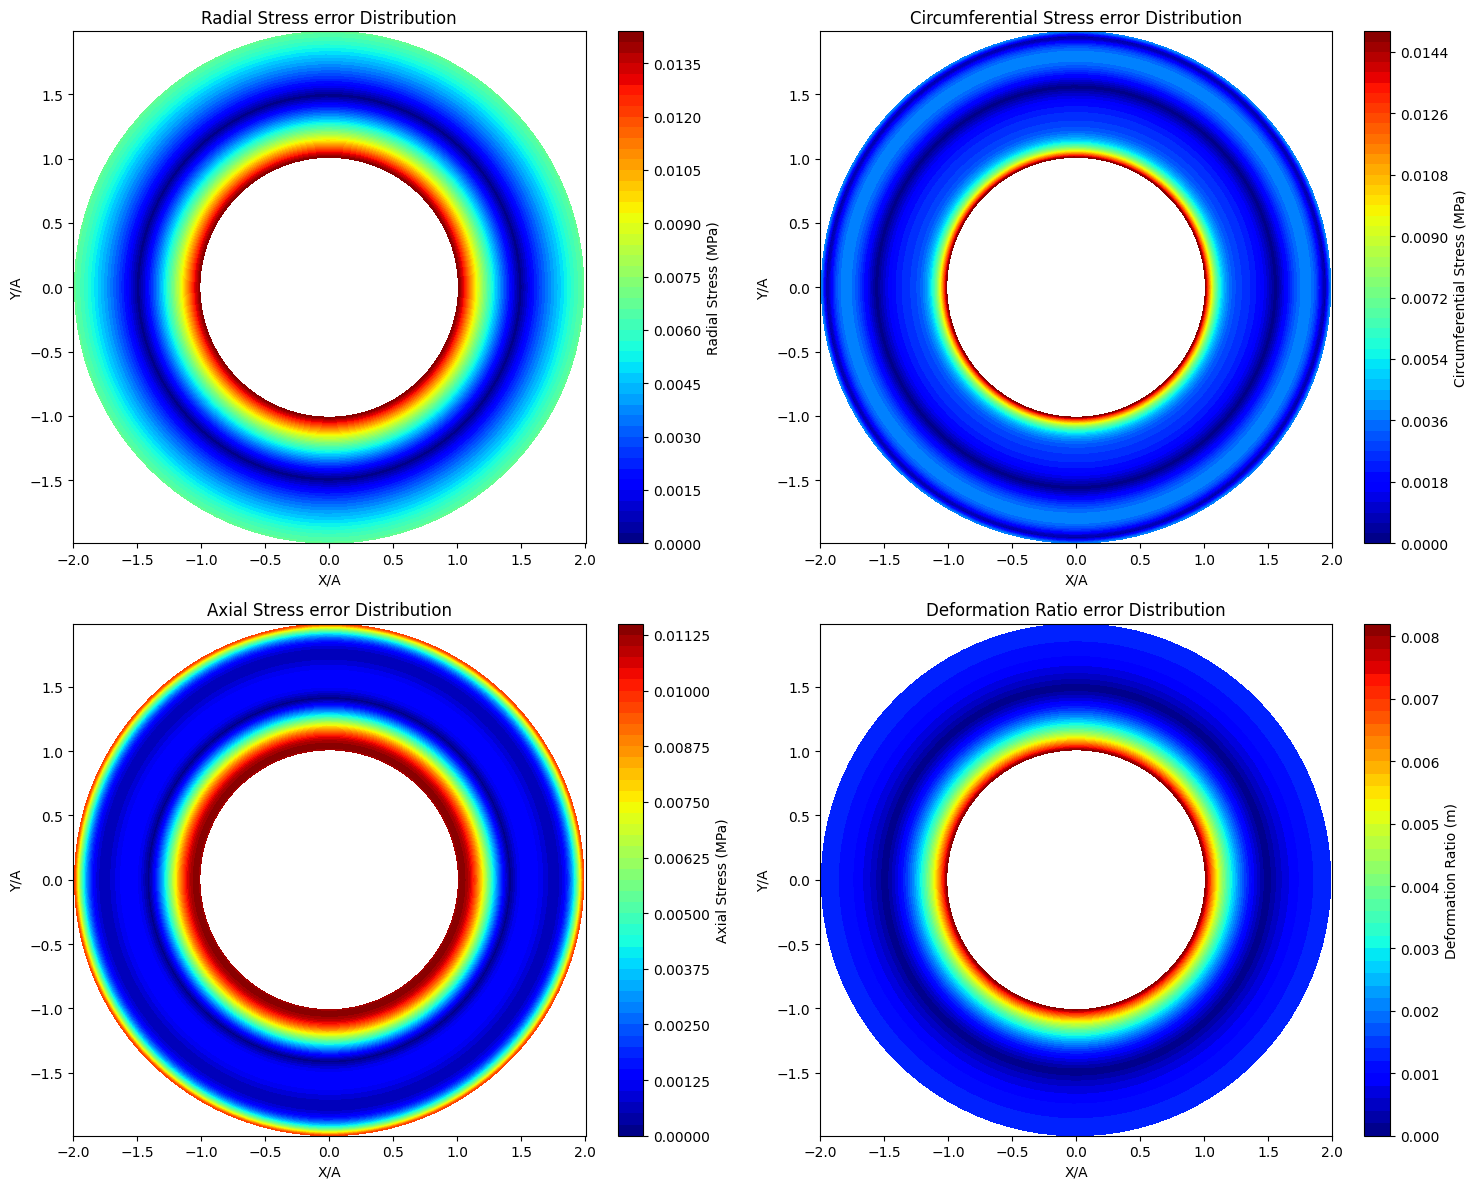

In [36]:
# 创建图形
plt.figure(figsize=(15, 12))
# 径向应力分布
plt.subplot(2, 2, 1)
contour1 = plt.contourf(X/A_bar, Y/A_bar, sigma_r_2d_error, 50, cmap='jet')
plt.colorbar(contour1, label='Radial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Radial Stress error Distribution')
plt.axis('equal')

# 环向应力分布
plt.subplot(2, 2, 2)
contour2 = plt.contourf(X/A_bar, Y/A_bar,sigma_theta_2d_error, 50, cmap='jet')
plt.colorbar(contour2, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Circumferential Stress error Distribution')
plt.axis('equal')

# 轴向应力分布
plt.subplot(2, 2, 3)
contour3 = plt.contourf(X/A_bar, Y/A_bar,sigma_z_2d_error, 50, cmap='jet')
plt.colorbar(contour3, label='Axial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Axial Stress error Distribution')
plt.axis('equal')

# 变形比分布
plt.subplot(2, 2, 4)
contour4 = plt.contourf(X/A_bar, Y/A_bar, lamdatheta_2d_error, 50, cmap='jet')
plt.colorbar(contour4, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('Deformation Ratio error Distribution')
plt.axis('equal')

plt.tight_layout()
plt.savefig(r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\error_2D.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()

In [37]:
# 计算L2相对误差
def L2_relative_error(true_values, computed_values):
    numerator = np.sqrt(np.sum((true_values - computed_values) ** 2))  # 分子：计算误差的L2范数
    denominator = np.sqrt(np.sum(true_values ** 2))  # 分母：实际值的L2范数
    return numerator / denominator

In [38]:
# 计算各个误差
sigma_r_2d_L2_error = L2_relative_error(sigma_r_2d, COMSOL_sigma_r_2d)
sigma_theta_2d_L2_error = L2_relative_error(sigma_theta_2d, COMSOL_sigma_theta_2d)
sigma_z_2d_L2_error = L2_relative_error(sigma_z_2d, COMSOL_sigma_z_2d)
lamdatheta_2d_L2_error = L2_relative_error(lamdatheta_2d, COMSOL_lamdatheta_2d)

In [39]:
# 打印误差结果
print(f"Sigma_r 2D L2 Relative Error: {sigma_r_2d_L2_error}")
print(f"sigma_theta 2D L2 Relative Error: {sigma_theta_2d_L2_error}")
print(f"Sigma_z 2D L2 Relative Error: {sigma_z_2d_L2_error}")
print(f"lamdatheta_2d L2 Relative Error: {lamdatheta_2d_L2_error}")

Sigma_r 2D L2 Relative Error: 0.011962248287564434
sigma_z 2D L2 Relative Error: 0.002310112280663476
Sigma_theta 2D L2 Relative Error: 0.010931367771290898
lamdatheta_2d L2 Relative Error: 0.002185836559458839


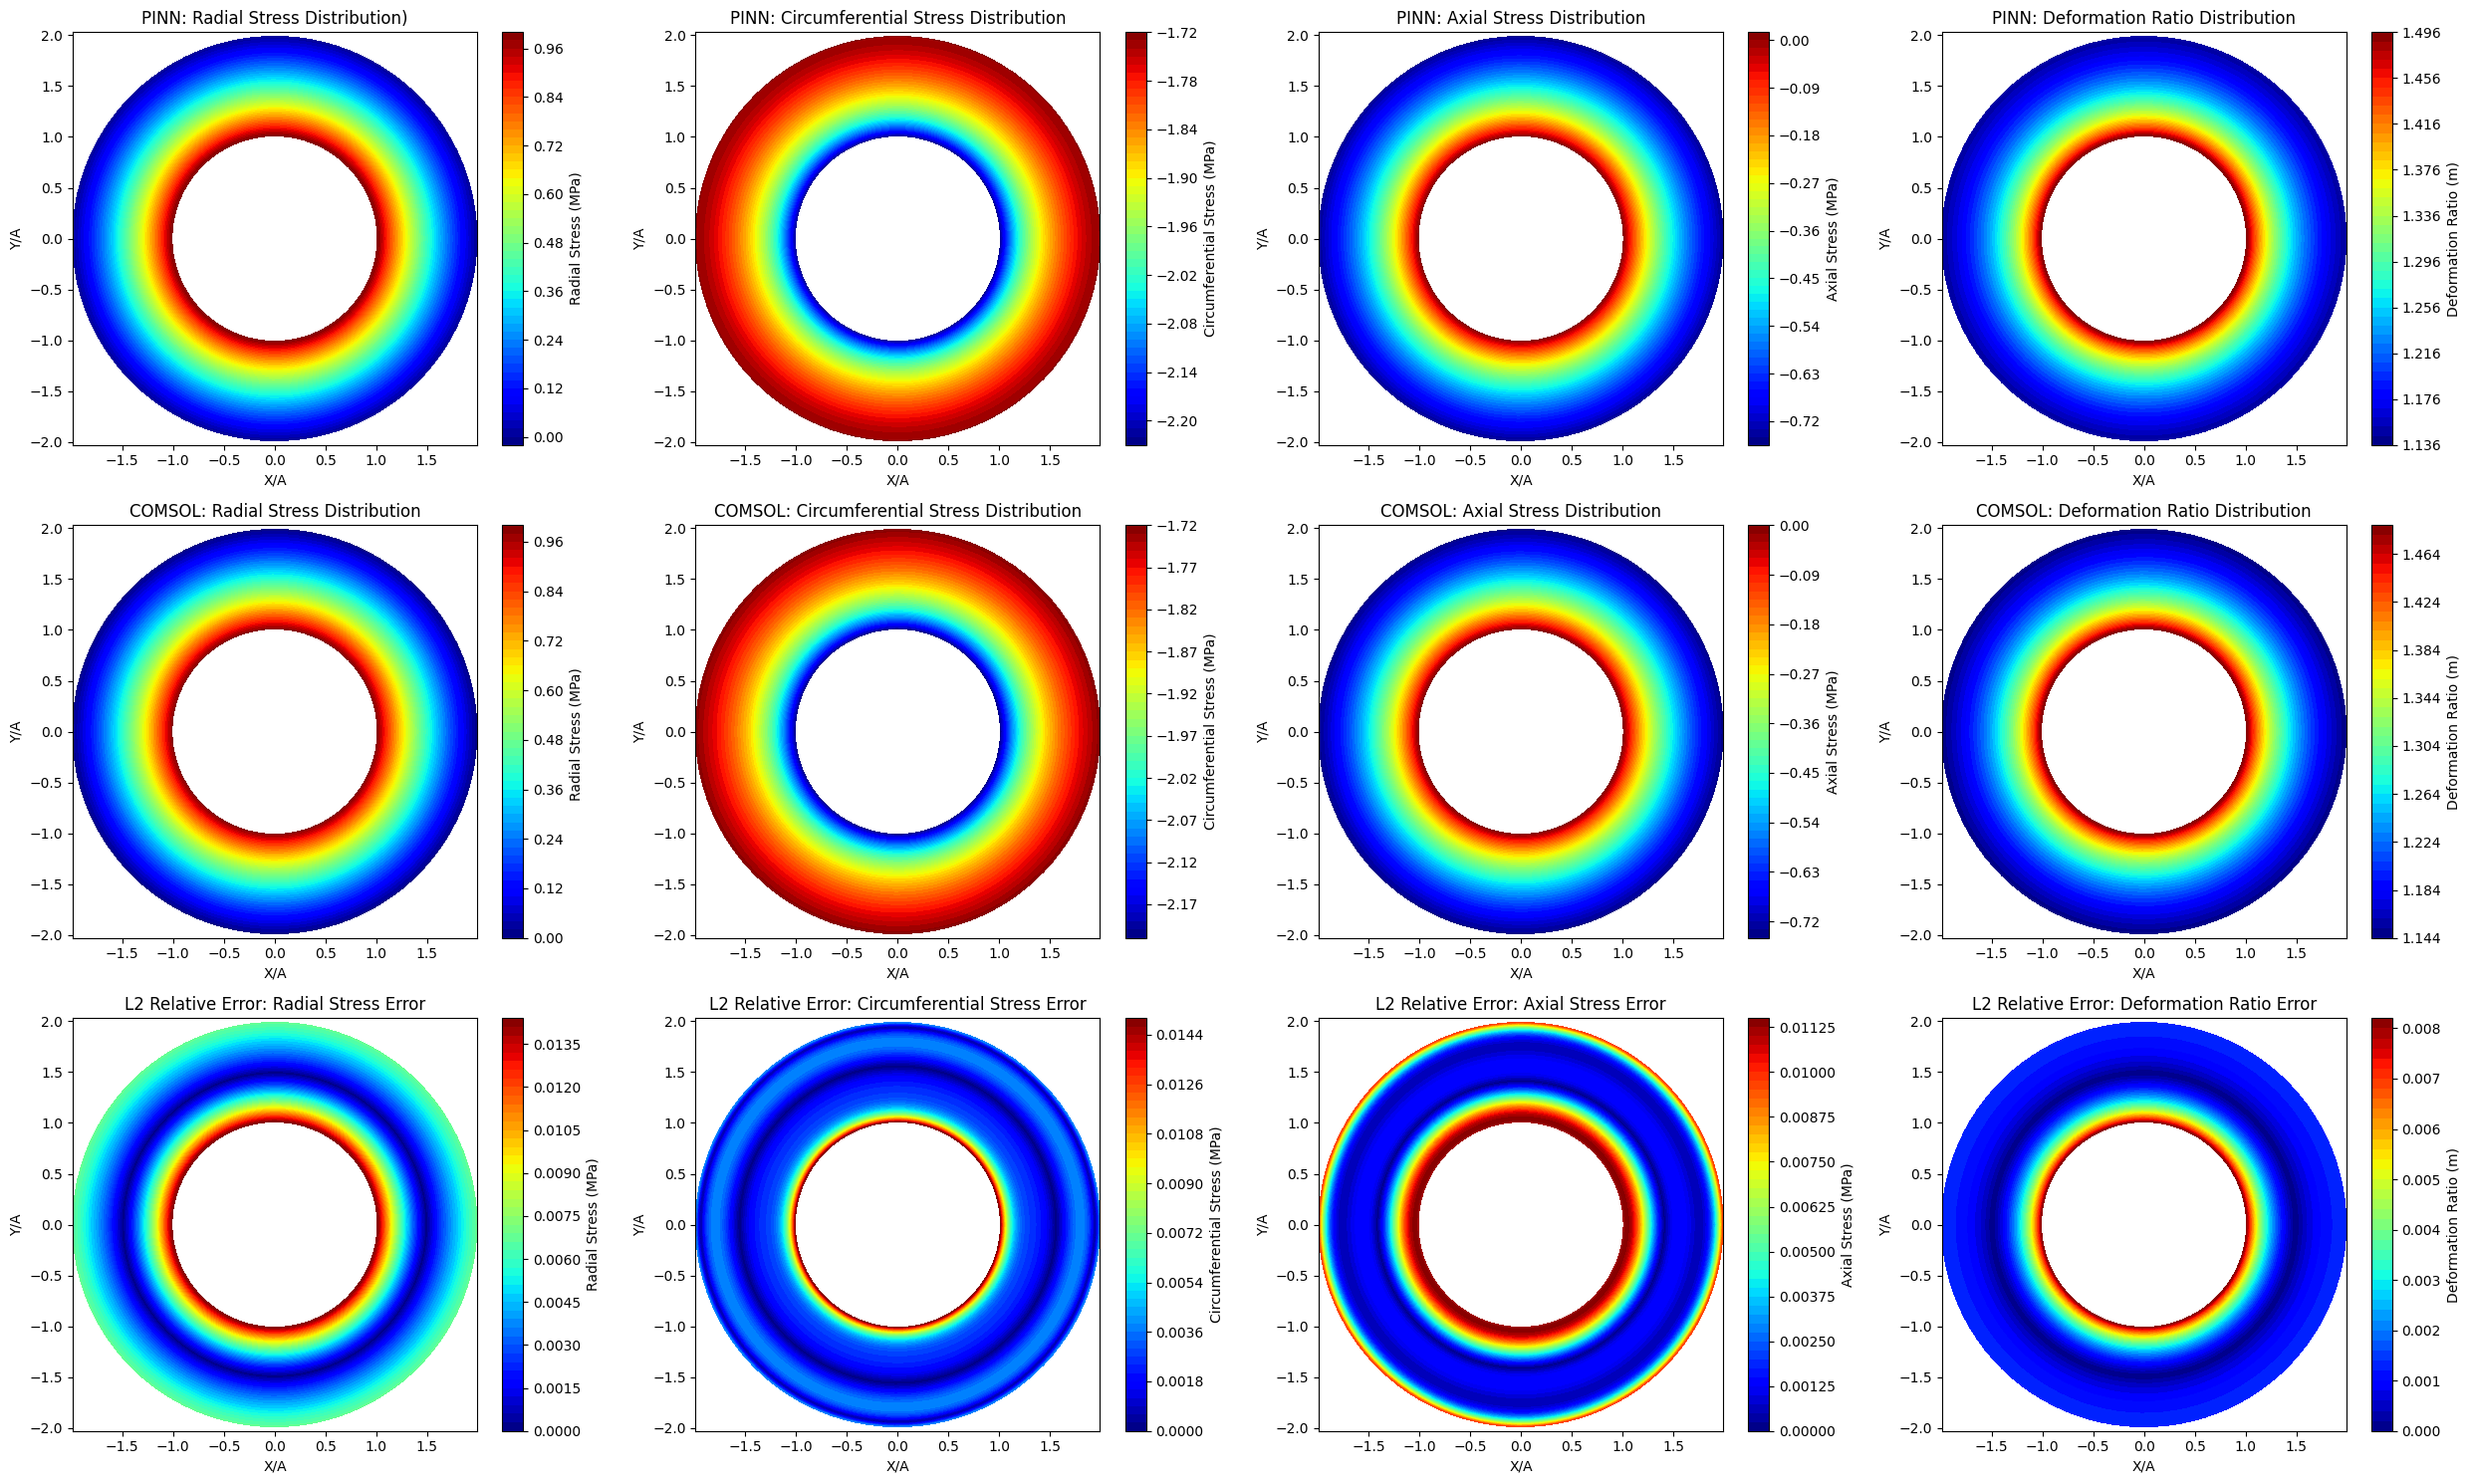

In [40]:
# 创建图形3x3排列
plt.figure(figsize=(25, 15))

# 第一排：PINN结果

# 第一列：PINN径向应力
plt.subplot(3, 4, 1)

contour1 = plt.contourf(X/A_bar, Y/A_bar, sigma_r_2d, 50, cmap='jet')
plt.colorbar(contour1,label='Radial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Radial Stress Distribution)')
plt.axis('equal')

# 第二列：PINN环向应力
plt.subplot(3, 4, 2)

contour2 = plt.contourf(X/A_bar, Y/A_bar, sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour2, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Circumferential Stress Distribution')
plt.axis('equal')

# 第三列：PINN轴向应力
plt.subplot(3, 4, 3)

contour3 = plt.contourf(X/A_bar, Y/A_bar, sigma_z_2d, 50, cmap='jet')

plt.colorbar(contour3, label='Axial Stress (MPa)')

plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Axial Stress Distribution')
plt.axis('equal')


# 第四列：PINN伸长比
plt.subplot(3, 4, 4)
contour4 = plt.contourf(X/A_bar, Y/A_bar, lamdatheta_2d, 50, cmap='jet')
plt.colorbar(contour4, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('PINN: Deformation Ratio Distribution')
plt.axis('equal')


# 第二排：FDM结果

# 第一列：FDM径向应力
plt.subplot(3, 4, 5)
contour5 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_sigma_r_2d, 50, cmap='jet')
plt.colorbar(contour5, label='Radial Stress (MPa) ')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Radial Stress Distribution')
plt.axis('equal')


# 第二列：COMSOL环向应力
plt.subplot(3, 4, 6)
contour6 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_sigma_theta_2d, 50, cmap='jet')
plt.colorbar(contour6, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Circumferential Stress Distribution')
plt.axis('equal')


# 第三列：COMSOL轴向应力
plt.subplot(3, 4, 7)
contour7 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_sigma_z_2d, 50, cmap='jet')
plt.colorbar(contour7, label='Axial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Axial Stress Distribution')
plt.axis('equal')


# 第四列：COMSOL伸长比
plt.subplot(3, 4, 8)
contour8 = plt.contourf(X/A_bar, Y/A_bar, COMSOL_lamdatheta_2d, 50, cmap='jet')
plt.colorbar(contour8, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('COMSOL: Deformation Ratio Distribution')
plt.axis('equal')



# 第三排：误差

# 第一列：位移误差
plt.subplot(3, 4, 9)
contour9 = plt.contourf(X/A_bar, Y/A_bar, sigma_r_2d_error, 50, cmap='jet')
plt.colorbar(contour9, label='Radial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('L2 Relative Error: Radial Stress Error')
plt.axis('equal')

# 第二列：径向应力误差
plt.subplot(3, 4, 10)
contour10 = plt.contourf(X/A_bar, Y/A_bar,sigma_theta_2d_error, 50, cmap='jet')
plt.colorbar(contour10, label='Circumferential Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('L2 Relative Error: Circumferential Stress Error')
plt.axis('equal')



# 第三列：环向应力误差
plt.subplot(3, 4, 11)
contour11 = plt.contourf(X/A_bar, Y/A_bar,sigma_z_2d_error, 50, cmap='jet')
plt.colorbar(contour11, label='Axial Stress (MPa)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('L2 Relative Error: Axial Stress Error')
plt.axis('equal')



# 第四列：环向应力误差
plt.subplot(3, 4, 12)
contour12 = plt.contourf(X/A_bar, Y/A_bar, lamdatheta_2d_error, 50, cmap='jet')
plt.colorbar(contour12, label='Deformation Ratio (m)')
plt.xlabel('X/A')
plt.ylabel('Y/A')
plt.title('L2 Relative Error: Deformation Ratio Error')
plt.axis('equal')

# 调整布局以避免标签重叠
plt.tight_layout()

plt.savefig(r'D:\李辉\超弹性球柱PINN求解\hyperelastic cylindrical shell_zhu_mi_double_forward problem\NH model\sanzu_2D_distribution.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()
